In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

In [3]:
path = kagglehub.dataset_download("mohamedbakhet/amazon-books-reviews")
print(f"Датасет скачан в: {path}")

100%|██████████| 1.06G/1.06G [00:57<00:00, 19.9MB/s]

Extracting files...


Датасет скачан в: /root/.cache/kagglehub/datasets/mohamedbakhet/amazon-books-reviews/versions/1


In [4]:
# Загрузка датасета
df = pd.read_csv(os.path.join(path, 'Books_rating.csv'))
df = df.rename(columns={
    'User_id': 'user_id',
    'Id': 'book_id',
    'Title': 'title',
    'review/score': 'rating',
    'review/time': 'date_read'
})
df['date_read'] = pd.to_datetime(df['date_read'], unit='s', errors='coerce')

books = pd.read_csv(os.path.join(path, 'books_data.csv'))

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 10 columns):
 #   Column              Dtype         
---  ------              -----         
 0   book_id             object        
 1   title               object        
 2   Price               float64       
 3   user_id             object        
 4   profileName         object        
 5   review/helpfulness  object        
 6   rating              float64       
 7   date_read           datetime64[ns]
 8   review/summary      object        
 9   review/text         object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 228.9+ MB


In [6]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212404 entries, 0 to 212403
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Title          212403 non-null  object 
 1   description    143962 non-null  object 
 2   authors        180991 non-null  object 
 3   image          160329 non-null  object 
 4   previewLink    188568 non-null  object 
 5   publisher      136518 non-null  object 
 6   publishedDate  187099 non-null  object 
 7   infoLink       188568 non-null  object 
 8   categories     171205 non-null  object 
 9   ratingsCount   49752 non-null   float64
dtypes: float64(1), object(9)
memory usage: 16.2+ MB


In [7]:
df.head()

,book_id,title,Price,user_id,profileName,review/helpfulness,rating,date_read,review/summary,review/text
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,1999-10-23,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,2004-09-21,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,0826414346,Dr. Seuss: American Icon,NaN,A3UH4UZ4RSVO82,John Granger,10/11,5.0,2004-03-09,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,0826414346,Dr. Seuss: American Icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",7/7,4.0,2004-07-25,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,0826414346,Dr. Seuss: American Icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",3/3,4.0,2005-02-10,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...


In [8]:
books.head()

,Title,description,authors,image,previewLink,publisher,publishedDate,infoLink,categories,ratingsCount
0,Its Only Art If Its Well Hung!,NaN,['Julie Strain'],http://books.google.com/books/content?id=DykPA...,http://books.google.nl/books?id=DykPAAAACAAJ&d...,NaN,1996,http://books.google.nl/books?id=DykPAAAACAAJ&d...,['Comics & Graphic Novels'],NaN
1,Dr. Seuss: American Icon,Philip Nel takes a fascinating look into the k...,['Philip Nel'],http://books.google.com/books/content?id=IjvHQ...,http://books.google.nl/books?id=IjvHQsCn_pgC&p...,A&C Black,2005-01-01,http://books.google.nl/books?id=IjvHQsCn_pgC&d...,['Biography & Autobiography'],NaN
2,Wonderful Worship in Smaller Churches,This resource includes twelve principles in un...,['David R. Ray'],http://books.google.com/books/content?id=2tsDA...,http://books.google.nl/books?id=2tsDAAAACAAJ&d...,NaN,2000,http://books.google.nl/books?id=2tsDAAAACAAJ&d...,['Religion'],NaN
3,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,['Veronica Haddon'],http://books.google.com/books/content?id=aRSIg...,http://books.google.nl/books?id=aRSIgJlq6JwC&d...,iUniverse,2005-02,http://books.google.nl/books?id=aRSIgJlq6JwC&d...,['Fiction'],NaN
4,"Nation Dance: Religion, Identity and Cultural ...",NaN,['Edward Long'],NaN,http://books.google.nl/books?id=399SPgAACAAJ&d...,NaN,2003-03-01,http://books.google.nl/books?id=399SPgAACAAJ&d...,NaN,NaN


In [9]:
books = books.rename(columns={
    'Title': 'title'
})

df = df.merge(books[['title', 'authors', 'categories']], on='title', how='left')
df['authors'] = df['authors'].fillna('unknown')
df['categories'] = df['categories'].fillna('unknown')

In [65]:
# убираем квадратные скобки у авторов и категорий
df['authors'] = df['authors'].apply(lambda x:
    x.strip("[]'").replace("'", "") if isinstance(x, str) else 'unknown'
)
df['categories'] = df['categories'].apply(lambda x:
    x.strip("[]'").replace("'", "") if isinstance(x, str) else 'unknown'
)
# приводим к одному регистру и убираем лишние пробелы и точки
df['authors'] = df['authors'].str.strip().str.lower().str.replace('.', '', regex=False)
df['categories'] = df['categories'].str.strip().str.lower().str.replace('.', '', regex=False)

df['authors'] = df['authors'].str.replace(r'\s+', ' ', regex=True)
df['categories'] = df['categories'].str.replace(r'\s+', ' ', regex=True)

In [10]:
df.head()

,book_id,title,Price,user_id,profileName,review/helpfulness,rating,date_read,review/summary,review/text,authors,categories
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,1999-10-23,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...,['Julie Strain'],['Comics & Graphic Novels']
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,2004-09-21,Really Enjoyed It,I don't care much for Dr. Seuss but after read...,['Philip Nel'],['Biography & Autobiography']
2,0826414346,Dr. Seuss: American Icon,NaN,A3UH4UZ4RSVO82,John Granger,10/11,5.0,2004-03-09,Essential for every personal and Public Library,"If people become the books they read and if ""t...",['Philip Nel'],['Biography & Autobiography']
3,0826414346,Dr. Seuss: American Icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",7/7,4.0,2004-07-25,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D...",['Philip Nel'],['Biography & Autobiography']
4,0826414346,Dr. Seuss: American Icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",3/3,4.0,2005-02-10,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...,['Philip Nel'],['Biography & Autobiography']


In [11]:
print(f"Записей: {len(df):,}")
print(f"Пользователей: {df['user_id'].nunique():,}")
print(f"Книг: {df['book_id'].nunique():,}")

Записей: 3,000,000
Пользователей: 1,008,972
Книг: 221,998


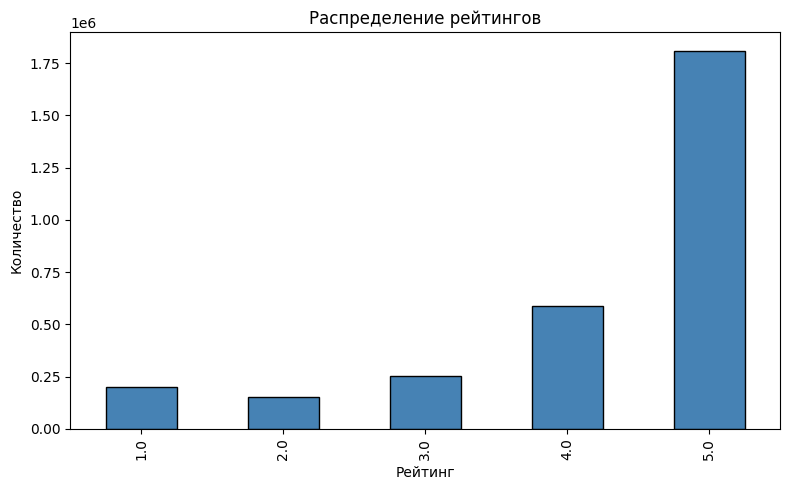

In [18]:
# Рейтинги
plt.figure(figsize=(8, 5))
df['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

Большинство рейтингов с оценкой 5

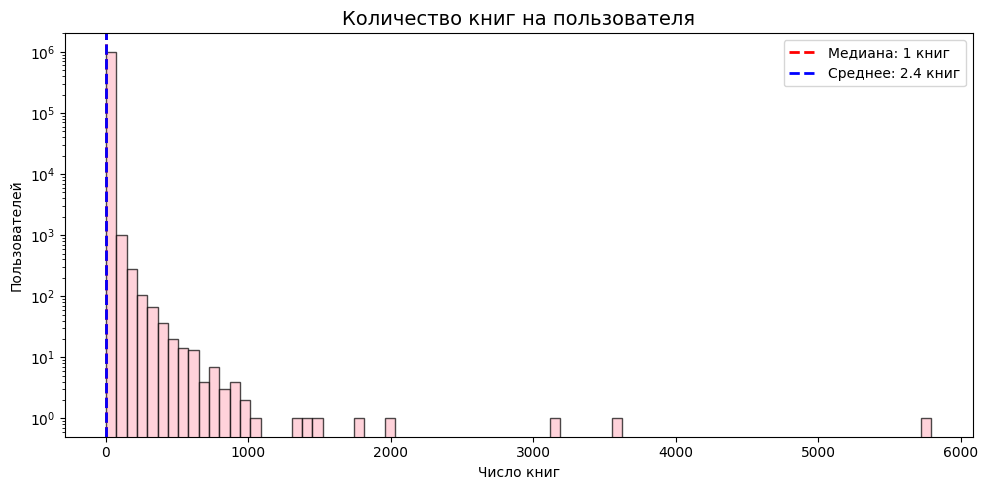

In [17]:
# Книги на пользователя
plt.figure(figsize=(10, 5))
user_cnt = df.groupby('user_id').size()  # сколько книг у каждого пользователя
plt.hist(user_cnt, bins=80, color='pink', edgecolor='black', alpha=0.7)
plt.axvline(user_cnt.median(), color='red', linestyle='--', linewidth=2,
            label=f'Медиана: {user_cnt.median():.0f} книг')
plt.axvline(user_cnt.mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Среднее: {user_cnt.mean():.1f} книг')
plt.title('Количество книг на пользователя', fontsize=14)
plt.xlabel('Число книг')
plt.ylabel('Пользователей')
plt.yscale('log')  # логарифмическая шкала (много пользователей с малым числом книг)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
test = df.groupby('user_id').count()['book_id']
test=test.reset_index()

In [42]:
test[test['book_id']>=5]

,user_id,book_id
2,A0015610VMNR0JC9XVL1,6
16,A00540411RKGTDNU543WS,9
26,A00878773S2MNB00COHKV,9
28,A00891092QIVH4W1YP46A,19
33,A01038432MVI9JXYTTK5T,24
...,...,...
1008888,AZZK8T7V8NQ9N,8
1008917,AZZQLMNX239VT,9
1008937,AZZUIE66HZNY1,13
1008945,AZZVZL4QEHEHO,25


In [39]:
test[test['book_id']>45]

,user_id,book_id
1517,A106016KSI0YQ,238
1614,A106E1N0ZQ4D9W,104
1835,A107C4RVRF0OP,72
2400,A10A1S5NAQBT21,63
2624,A10B4UOL0IB274,59
...,...,...
1005589,AZJHIRNFI04WK,56
1006072,AZM09BO1FD418,74
1007428,AZSNQ9FYC5SQO,105
1007465,AZSV99SDJC242,105


In [41]:
test[test['book_id']<2]

,user_id,book_id
0,A00109803PZJ91RLT7DPN,1
1,A00117421L76WVWG4UX95,1
3,A002258237PFYJV336T05,1
4,A00264602WCXBHHFPLTQ4,1
6,A00290423P2GEY37XWVAW,1
...,...,...
1008965,AZZYXDL4RWOBJ,1
1008966,AZZZ6G9WZTNNX,1
1008967,AZZZELE3I0CKD,1
1008968,AZZZJY3RMN57G,1


Датасет содержит 3 миллиона отзывов от 1008972 пользователей о 221998 книгах. Анализ распределения книг на пользователя показал, что около 69% пользователей имеют всего 1 книгу в истории (неактивный огромный хвост пользователей), и лишь 8% (82805) - 5 и более книг. Пользователи с единственной книгой не формируют последовательность и не могут быть использованы для обучения sequential-модели. Был выбран порог фильтрации в 5 и более книг выборка получается репрезентативной и подойдет для обучения.

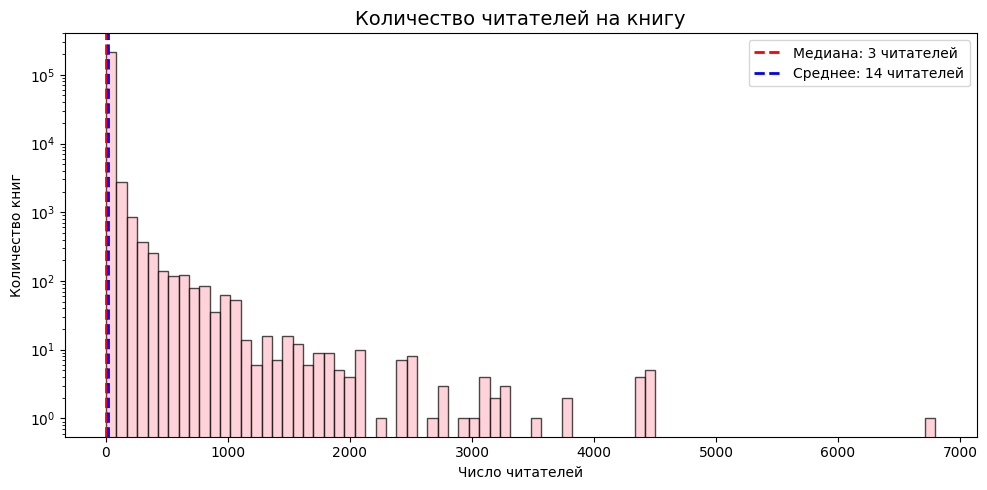

In [48]:
# Популярность книг
plt.figure(figsize=(10, 5))
book_cnt = df.groupby('book_id').size()  # сколько читателей у каждой книги
plt.hist(book_cnt, bins=80, color='pink', edgecolor='black', alpha=0.7)
plt.axvline(book_cnt.median(), color='red', linestyle='--', linewidth=2,
            label=f'Медиана: {book_cnt.median():.0f} читателей')
plt.axvline(book_cnt.mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Среднее: {book_cnt.mean():.0f} читателей')
plt.title('Количество читателей на книгу', fontsize=14)
plt.xlabel('Число читателей')
plt.ylabel('Количество книг')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

Распределение популярности книг имеет длинный хвост: медианное число читателей на книгу составляет 3, среднее — 14. Половина книг каталога имеют менее 3 читателей, что создаёт сложности для коллаборативной фильтрации. Данная проблема решается использованием контентных эмбеддингов авторов и категорий, которые позволяют модели формировать осмысленные представления даже для редких книг на основе их тематической близости.

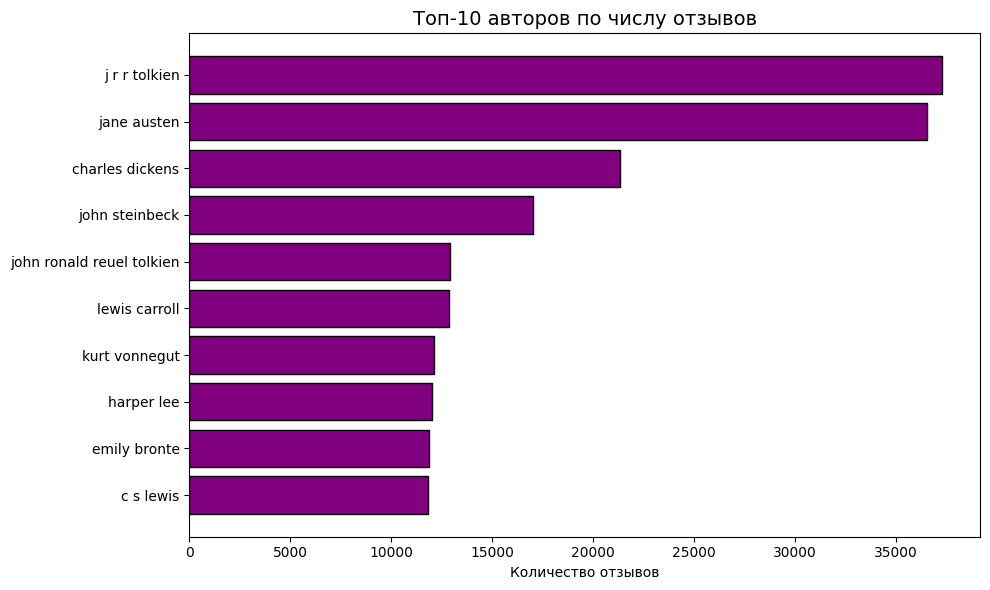

In [66]:
# Топ-10 авторов
plt.figure(figsize=(10, 6))
top_authors = df[df['authors'] != 'unknown']['authors'].value_counts().head(10)  # 10 самых частых авторов
plt.barh(range(10), top_authors.values, color='purple', edgecolor='black')
plt.yticks(range(10), [a[:30] for a in top_authors.index])  # обрезаем длинные имена
plt.title('Топ-10 авторов по числу отзывов', fontsize=14)
plt.xlabel('Количество отзывов')
plt.gca().invert_yaxis()  # самый популярный сверху
plt.tight_layout()
plt.show()

Как видим самые популярные авторы у нас это Толкиен, Остин и Диккенс. Также на графике обнаружены неявные дубликаты одно имя сокращенно другое польностью.Избавляться от них мы будем в файле предобработки данных.

In [57]:
top_authors

,count
authors,
J. R. R. Tolkien,37268
Jane Austen,36532
Charles Dickens,21270
John Steinbeck,17027
John Ronald Reuel Tolkien,12906
Lewis Carroll,12847
Kurt Vonnegut,12124
Harper Lee,12013
Emily Bronte,11872


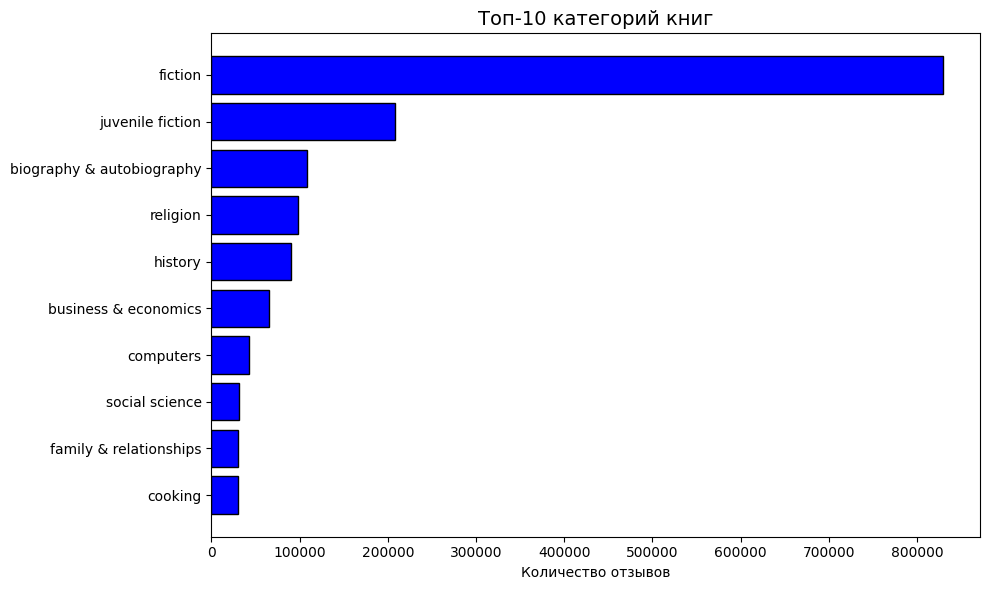

In [77]:
# Топ-10 категорий
plt.figure(figsize=(10, 6))
top_cats = df[df['categories'] != 'unknown']['categories'].value_counts().head(10)  # 10 самых частых категорий
plt.barh(range(10), top_cats.values, color='blue', edgecolor='black')
plt.yticks(range(10), [c[:30] for c in top_cats.index])
plt.title('Топ-10 категорий книг', fontsize=14)
plt.xlabel('Количество отзывов')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Fiction — это художественная литература (романы, повести, рассказы). Самая популярная категория в англоязычных книжных датасетах.


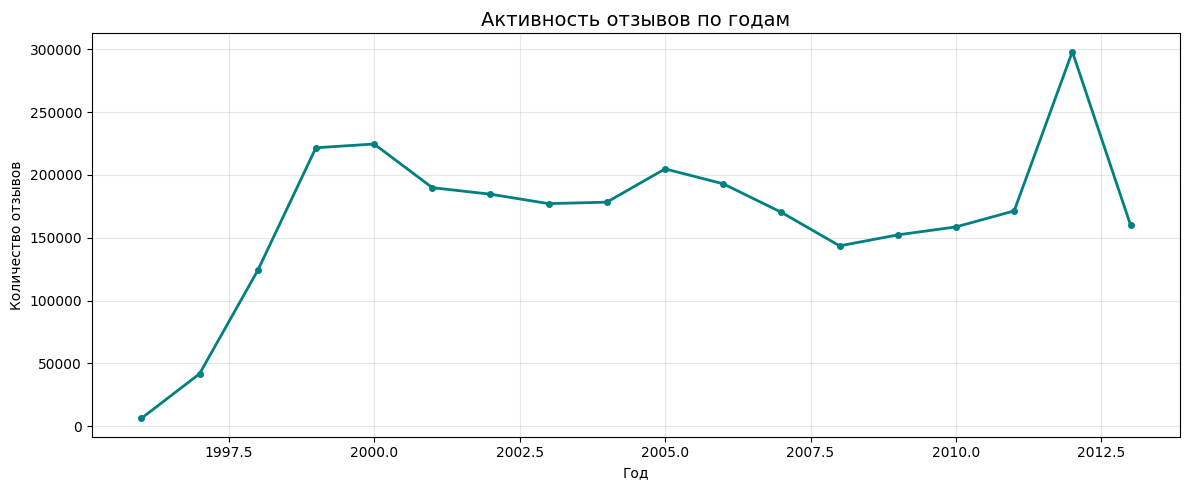

In [79]:
# Активность по годам
plt.figure(figsize=(12, 5))
df['year'] = df['date_read'].dt.year  # год из даты
yearly = df.groupby('year').size()     # отзывы по годам
yearly = yearly[yearly.index > 1995]   # отсекаем слишком старые
plt.plot(yearly.index, yearly.values, marker='o', color='teal',
         linewidth=2, markersize=4)
plt.title('Активность отзывов по годам', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Количество отзывов')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Большинство всего отзывов с 2010 по 2012 год. Увеличение популярности отзывов к 2000 году

